# rs-embed Playground
<img src="https://raw.githubusercontent.com/cybergis/rs-embed/main/docs/assets/background.png" width="800" /> 

The remote sensing community is witnessing a rapid growth of foundation models, which provide powerful embeddings for a wide range of downstream tasks. However, practical adoption and fair comparison remain challenging due to substantial heterogeneity in model release formats, platforms and interfaces, and input data specifications. These inconsistencies significantly increase the cost of obtaining, using, and benchmarking embeddings across models. To address this issue, we propose rs-embed, a Python library that offers a unified, region of interst (ROI) centric interface: with a single line of code, users can retrieve embeddings from any supported model for any location and any time range. The library also provides efficient batch processing to enable large-scale embedding generation and evaluation. 

This notebook demonstrates **direct usage** from `rs_embed`.



The goal is to clearly expose the **core toolkit API**:
- spatial inputs (`PointBuffer`, `BBox`)
- temporal specs (`year`, `range`)
- output specs (`pooled`, `grid`)
- returned `data` and `meta`

> Select Kernel: `rsembed`



In [ ]:
!git clone https://github.com/cybergis/rs-embed.git
%cd rs-embed
%pip install -e .

In [12]:
!earthengine authenticate

Authenticate: Credentials already exist. Use --force to refresh.


For the first installation, please restart the kernel.

In [1]:
from rs_embed import BBox, PointBuffer, TemporalSpec, OutputSpec, SensorSpec
from rs_embed import inspect_gee_patch, get_embedding, get_embeddings_batch, export_batch
from plot_utils import *

import json

## 1. Define spatial and temporal inputs

In [2]:
# Spatial: point + buffer
spatial_point = PointBuffer(
    lon=121.5,  # , -122.407677
    lat=31.2,  # 37.787937
    buffer_m=2048,
)

# Spatial: bounding box
spatial_bbox = BBox(
    minlon=121.45,
    minlat=31.15,
    maxlon=121.65,
    maxlat=31.25,
)

# Temporal: single year
temporal_year = TemporalSpec.year(2024)

# Temporal: date range
temporal_range = TemporalSpec.range(
    "2022-06-01",
    "2022-09-01",
)

spatial_point, spatial_bbox, temporal_year, temporal_range

(PointBuffer(lon=121.5, lat=31.2, buffer_m=2048, crs='EPSG:4326'),
 BBox(minlon=121.45, minlat=31.15, maxlon=121.65, maxlat=31.25, crs='EPSG:4326'),
 TemporalSpec(mode='year', year=2024, start=None, end=None),
 TemporalSpec(mode='range', year=<function TemporalSpec.year at 0x14aff98582c0>, start='2022-06-01', end='2022-09-01'))

## 2. `get_embedding()` : One Point x One Model



### 2.1 Basic usgae


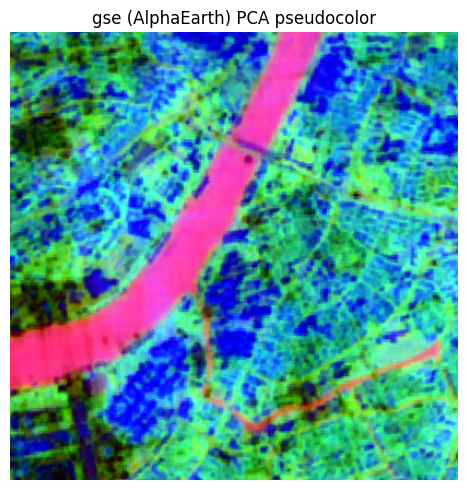

In [3]:
emb = get_embedding(
    "gse",
    spatial=spatial_point,
    temporal=temporal_year,
    output=OutputSpec.grid(),
    backend="gee",
)

# print("data.shape:", emb.data.shape)
# print("source:", emb.meta.get("source"))

pca = plot_embedding_pseudocolor(
    emb,
    title="gse (AlphaEarth) PCA pseudocolor",
)

### 2.2 InputSpec: `resize` v.s `tile`
Different models have different input image size requirements. Therefore, we provide two methods for preprocessing the input region images:
- `resize`: Resize the region image to the size required by the model. However, this may lead to some loss of spatial detail.
- `tiles`: Split the region image into multiple images that each satisfy the model’s input size requirement, and then merge them at the feature level. Since this can cause the computational cost to grow exponentially, we do not recommend using this option for large-scale processing unless you have resource to doing so. To prevent the program from freezing, the default `max_tiles` is set to `9`. If you want to change this, you can pass an `InputPrepSpec` in `input_prep` to specify more detailed settings.

> We use resize by default.

For more information, [click here](https://cybergis.github.io/rs-embed/api_specs/)

/u/dingqi2/miniconda3/envs/rsembed_t/lib/python3.12/site-packages/torch/cuda/__init__.py:1007: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()


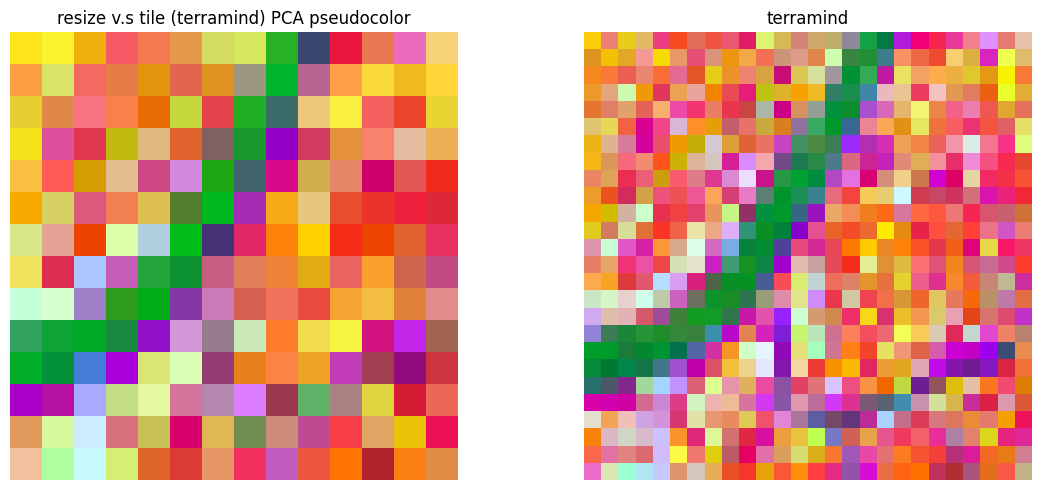

In [4]:
# from rs_embed import InputPrepSpec
emb_resize = get_embedding(
    "terramind",  # "", #terramind
    spatial=spatial_point,
    temporal=temporal_range,
    output=OutputSpec.grid(),
    input_prep="resize",
    backend="gee",
)

emb_tile = get_embedding(
    "terramind",  # "", #terramind
    spatial=spatial_point,
    temporal=temporal_range,
    output=OutputSpec.grid(),
    input_prep="tile",
    backend="gee",
)

pca = plot_embedding_pseudocolor(
    emb=emb_resize,
    emb2=emb_tile,
    title="resize v.s tile (terramind) PCA pseudocolor",
)

### 2.3 OutputSpec: `pooled()` v.s `grid()`

In [5]:
emb_pooled = get_embedding(
    "remoteclip",
    spatial=spatial_point,
    temporal=temporal_range,
    output=OutputSpec.pooled(),
    backend="gee",
)

emb_grid = get_embedding(
    "remoteclip",
    spatial=spatial_point,
    temporal=temporal_range,
    output=OutputSpec.grid(),
    backend="gee",
)

print("pooled shape:", emb_pooled.data.shape)
print("grid shape:", emb_grid.data.shape)

/u/dingqi2/miniconda3/envs/rsembed_t/lib/python3.12/site-packages/torch/cuda/__init__.py:1007: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights from local directory
pooled shape: (768,)
grid shape: (768, 7, 7)


/u/dingqi2/miniconda3/envs/rsembed_t/lib/python3.12/site-packages/torch/cuda/__init__.py:1007: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()


## 4. `get_embeddings_batch()`: Multi Point x One model

In [6]:
from rs_embed import get_embeddings_batch

points = [
    PointBuffer(lon=121.5, lat=31.2, buffer_m=100),
    PointBuffer(lon=121.6, lat=31.3, buffer_m=100),
    PointBuffer(lon=120.0, lat=30.0, buffer_m=100),
]

embeddings = get_embeddings_batch(
    "satmae", spatials=points, temporal=temporal_range, output=OutputSpec.grid(), backend="gee"
)

for i, emb in enumerate(embeddings):
    print(f"Embedding {i} shape: {emb.data.shape}")

/u/dingqi2/miniconda3/envs/rsembed_t/lib/python3.12/site-packages/torch/cuda/__init__.py:1007: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()


Embedding 0 shape: (1024, 14, 14)
Embedding 1 shape: (1024, 14, 14)
Embedding 2 shape: (1024, 14, 14)


## 5. `export_batch()`: Multi Poinst x Multi Models
>  This API is designed for **rapid batch processing**. 
- Minimal example: export multi-point inputs + embeddings + manifest.
- Then inspect one file with a single helper call.

For more infor, [Click here](https://cybergis.github.io/rs-embed/api_export/)

In [7]:
from rs_embed import ExportConfig, ExportTarget, ExportModelRequest

manifest = export_batch(
    spatials=[
        PointBuffer(lon=121.5, lat=31.2, buffer_m=200),
        PointBuffer(lon=120.5, lat=30.2, buffer_m=200),
    ],
    temporal=temporal_range,
    models=[
        ExportModelRequest(name="remoteclip"),
        ExportModelRequest(name="terrafm", modality="s2"),
    ],  # or you can specify as ["remoteclip", "terrafm"]
    target=ExportTarget.per_item("exports", names=["p1", "p2"]),
    output=OutputSpec.pooled(),
    config=ExportConfig(save_inputs=True),
    backend="gee",
)

export_batch:   0%|          | 0/2 [00:00<?, ?point/s]

infer[remoteclip]:   0%|          | 0/2 [00:00<?, ?point/s]

infer[terrafm]:   0%|          | 0/2 [00:00<?, ?point/s]

/u/dingqi2/miniconda3/envs/rsembed_t/lib/python3.12/site-packages/torch/cuda/__init__.py:1007: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights from local directory


/u/dingqi2/miniconda3/envs/rsembed_t/lib/python3.12/site-packages/torch/cuda/__init__.py:1007: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()
/u/dingqi2/miniconda3/envs/rsembed_t/lib/python3.12/site-packages/torch/cuda/__init__.py:1007: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()
/u/dingqi2/miniconda3/envs/rsembed_t/lib/python3.12/site-packages/torch/cuda/__init__.py:1007: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()


Inspect one exported file (read + summary + exact input visualization)


=== Manifest summary ===
npz_path: None
backend: gee
spatial: {'lon': 121.5, 'lat': 31.2, 'buffer_m': 200, 'crs': 'EPSG:4326'}
temporal: {'mode': 'range', 'year': '<function TemporalSpec.year at 0x14aff98582c0>', 'start': '2022-06-01', 'end': '2022-09-01'}
npz_keys: ['input_chw__remoteclip', 'embedding__remoteclip', 'input_chw__terrafm', 'embedding__terrafm']

=== model -> input key ===
remoteclip: input_chw__remoteclip
terrafm: input_chw__terrafm

=== Visualizing exact model inputs ===
input_chw__remoteclip <- remoteclip      shape=(3, 41, 41) dtype=float32 min=0 max=3.35e+03


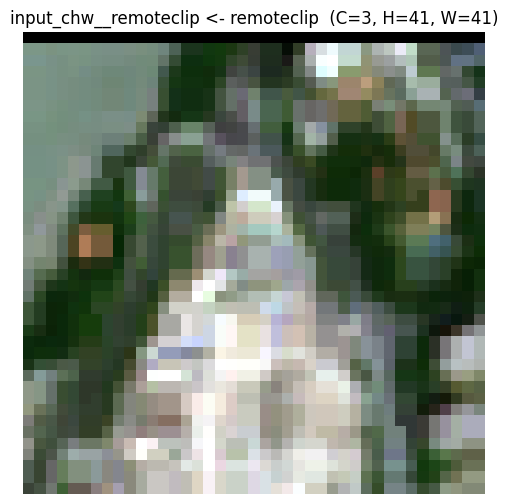

input_chw__terrafm <- terrafm            shape=(12, 41, 41) dtype=float32 min=0 max=4.57e+03


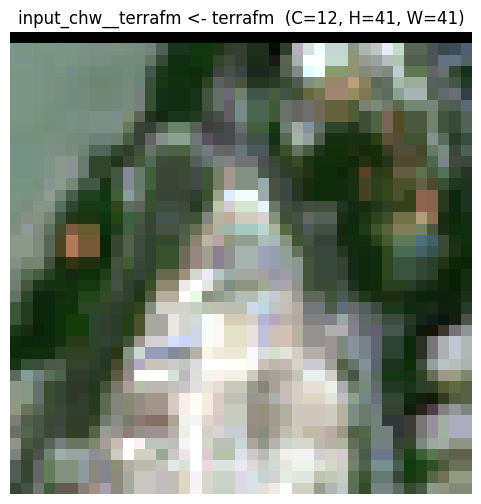

In [8]:
manifest, z = inspect_export_npz("exports/p1.npz")

## 6. Checkout the original area


ok: True


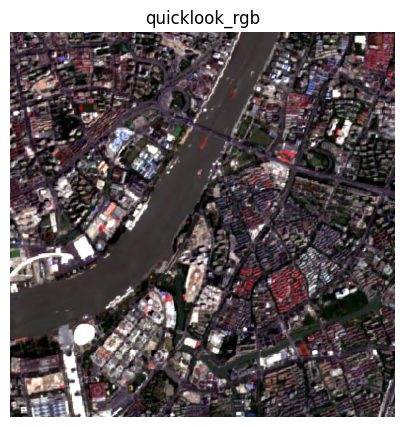

In [9]:
check_out = inspect_gee_patch(
    spatial=spatial_point,
    temporal=temporal_range,
    sensor=SensorSpec(
        collection="COPERNICUS/S2_SR_HARMONIZED",
        bands=("B4", "B3", "B2"),
        scale_m=10,
        cloudy_pct=10,
        composite="median",
        fill_value=0.0,
        check_save_dir="./_gee_checks",
    ),
    value_range=(0, 10000),
)

print("ok:", check_out.get("ok"))
show_quicklook_artifact(check_out.get("artifacts") or {})

ok: False
bands: ('VV', 'VH')
S1 CHW: (2, 410, 410) float32 min= -26.330251693725586 max= 33.094207763671875


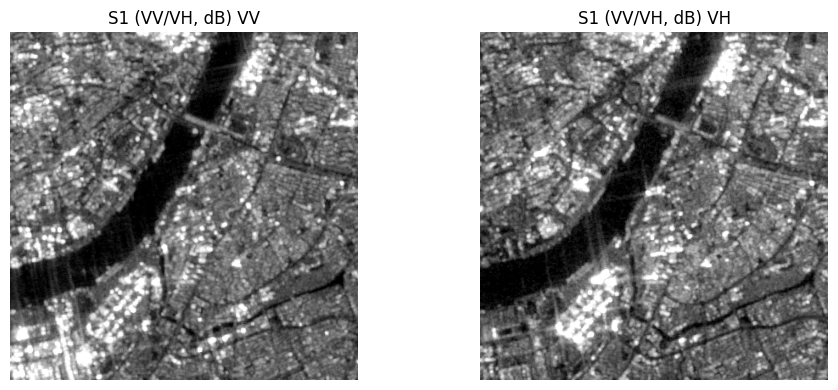

In [10]:
# Sentinel-1 (VV/VH) inspection for the same region/time window
s1_check_out = inspect_gee_patch(
    spatial=spatial_point,
    temporal=temporal_range,
    sensor=SensorSpec(
        collection="COPERNICUS/S1_GRD",  # dB-scale backscatter
        bands=("VV", "VH"),
        scale_m=10,
        cloudy_pct=None,
        composite="median",
        fill_value=-35.0,
        check_save_dir="./_gee_checks",
    ),
    name="s1_vvvh_patch",
    value_range=(-50, 10),
    return_array=True,
)

show_s1_vvvh_from_inspect(s1_check_out, title_prefix="S1 (VV/VH, dB)")